In [2]:
import torch

import xarray as xr
import numpy as np
import pandas as pd

from constants import *
from neural_net import get_net

from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy
import cmocean

In [3]:
torch.manual_seed(10)

# Settings

In [4]:
device = torch.device("cuda:1")
dtype = torch.bfloat16

In [5]:
batch_size = 64

# Number of ensemble members
n_ensemble = 4

# Integration steps for flow model
n_int = 1

# 15 day forecast length
n_forecast_length = 10

lead_time_axis = pd.Timedelta("6h") * np.arange(1, n_forecast_length+1)

# Load data

In [6]:
ds_test = xr.open_zarr("../data/sqg_test.zarr")["q"].compute()

# Estimate score for persistence

In [7]:
initial_conditions = ds_test[:-n_forecast_length]
n_times_total = len(initial_conditions)
print(n_times_total) 

62


In [8]:
persistence_mse = []

pbar = tqdm(np.arange(0, n_times_total, batch_size))
for start_idx in pbar:
    curr_initial = initial_conditions[start_idx:start_idx+batch_size]

    # Loop over lead times
    batch_mse = []
    for ld in range(1, n_forecast_length+1):
        # Get prediction
        curr_prediction = curr_initial.values

        # Error estimation
        error = curr_prediction - ds_test[start_idx+ld:start_idx+len(curr_prediction)+ld]
        mse = ((error**2)).mean(["longitude", "latitude"])
        mse = mse.expand_dims(lead_time=[ld*pd.Timedelta("6h")]).assign_coords(time=curr_initial.indexes["time"])
        batch_mse.append(mse)
    batch_mse = xr.concat(batch_mse, dim="lead_time")
    persistence_mse.append(batch_mse)
persistence_mse = xr.concat(persistence_mse, dim="time")

  0%|          | 0/1 [00:00<?, ?it/s]

# Deterministic forecast

## Load neural network

In [9]:
n_blocks = 4
n_features = 64
det_model = get_net(
    n_input=1,
    n_output=1, n_blocks=n_blocks, n_features=n_features, mult=2,
    n_embedding=0, wave_length=0.1,
    device=device, dtype=dtype
)
state_dict = torch.load("../data/best_reg_model.ckpt", map_location="cpu")
det_model.load_state_dict(state_dict)
det_model = det_model.eval().to(device=device, dtype=dtype)

In [10]:
det_mse = []

pbar = tqdm(np.arange(0, n_times_total, batch_size))
for start_idx in pbar:
    curr_initial = initial_conditions[start_idx:start_idx+batch_size]
    curr_prediction = curr_initial.values

    # Loop over lead times
    batch_mse = []
    for ld in tqdm(range(1, n_forecast_length+1), leave=False):
        # Get prediction
        net_io = torch.from_numpy(curr_prediction)
        net_io = ((net_io-in_mean) / in_std).to(device=device, dtype=dtype)
        with torch.no_grad():
            net_io = det_model(net_io).cpu().float()
        curr_prediction = curr_prediction + (net_io * res_std + res_mean).numpy()

        # Error estimation
        error = curr_prediction - ds_test[start_idx+ld:start_idx+len(curr_prediction)+ld]
        mse = (error**2).mean(["longitude", "latitude"])
        mse = mse.expand_dims(lead_time=[ld*pd.Timedelta("6h")]).assign_coords(time=curr_initial.indexes["time"])
        batch_mse.append(mse)
    batch_mse = xr.concat(batch_mse, dim="lead_time")
    det_mse.append(batch_mse)
det_mse = xr.concat(det_mse, dim="time")

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

# Flow matching forecasts

In [11]:
delta_t = 1 / n_int

def sample_with_flow(flow_model, n_samples, H, W):
    device = next(flow_model.parameters()).device
    dtype = next(flow_model.parameters()).dtype
    dynamics = torch.randn(n_samples, 1, H, W, device=device, dtype=dtype)
    for t in np.linspace(0, 1, n_int+1)[:-1]:
        pseudo_time = torch.full((n_samples, 1), t, device=device, dtype=dtype)
        velocity = flow_model(dynamics, pseudo_time)
        dynamics = dynamics + delta_t * velocity
    return dynamics

In [12]:
ckpt = torch.load("../data/best_flowmodel_test.ckpt", map_location="cpu")
cfg = ckpt["config"]

flow_model = get_net(
    n_input=cfg["n_input"],
    n_output=cfg["n_output"],
    n_blocks=cfg["n_blocks"],
    n_features=cfg["n_features"],
    n_embedding=cfg["n_embedding"],
    wave_length=cfg["wave_length"],
    device=device,
    dtype=dtype,
)

# Load weights
flow_model.load_state_dict(ckpt["model_state_dict"])

# Switch to eval + move to device
flow_model = flow_model.eval().to(device=device, dtype=dtype)

# Optional: compile for speed
flow_model = torch.compile(flow_model, mode="reduce-overhead")

In [13]:
print("\n=== MODEL DEBUG ===")

first_conv = None
for m in flow_model.modules():
    if isinstance(m, torch.nn.Conv2d):
        first_conv = m
        break

print("First conv weight shape:", first_conv.weight.shape)
print("→ Model expects in_channels =", first_conv.weight.shape[1])


=== MODEL DEBUG ===
First conv weight shape: torch.Size([64, 2, 2, 2])
→ Model expects in_channels = 2


In [14]:
flow_mse_ens = []
flow_mse_mean = []
flow_spread = []

# divide in batches and iterate over them 
# whta is a good number of batches to choose? 
pbar = tqdm(np.arange(0, n_times_total, batch_size))
for start_idx in pbar:
    curr_initial = initial_conditions[start_idx:start_idx+batch_size]
    curr_prediction = curr_initial.values

    # Add ensemble dimension
    curr_prediction = curr_prediction[None].repeat(n_ensemble, axis=0)

    # Loop over lead times
    batch_mse_ens = []
    batch_mse_mean = []
    batch_spread = []
    for ld in tqdm(range(1, n_forecast_length+1), leave=False):
        # curr_prediction shape: (n_ensemble, batch_size, 1, 512, 512)
        n_ens, n_batch, C, H, W = curr_prediction.shape
        with torch.no_grad():
            net_io = sample_with_flow(flow_model, n_samples=n_ens * n_batch, H=H, W=W)
            net_io = net_io.reshape(n_ens, n_batch, C, H, W).cpu().float()
        curr_prediction = curr_prediction + (net_io * res_std + res_mean).numpy()

        # Error estimation for ensemble members
        truth = ds_test[start_idx+ld:start_idx+curr_prediction.shape[1]+ld]
        truth = truth.expand_dims(ensemble=np.arange(n_ensemble), axis=0)
        error = curr_prediction - truth
        mse = (error**2).mean(["ensemble", "longitude", "latitude"])
        mse = mse.expand_dims(lead_time=[ld*pd.Timedelta("6h")]).assign_coords(time=curr_initial.indexes["time"])
        batch_mse_ens.append(mse)

        # Error estimation for ensemble mean
        truth = ds_test[start_idx+ld:start_idx+curr_prediction.shape[1]+ld]
        error = curr_prediction.mean(axis=0) - truth
        mse = ((error**2)).mean(["longitude", "latitude"])
        mse = mse.expand_dims(lead_time=[ld*pd.Timedelta("6h")]).assign_coords(time=curr_initial.indexes["time"])
        batch_mse_mean.append(mse)

        # Estimate spread as ensemble variance
        variance = curr_prediction.var(axis=0, ddof=1)
        variance = ds_test[start_idx+ld:start_idx+curr_prediction.shape[1]+ld].copy(data=variance)
        variance = (variance).mean(["longitude", "latitude"])
        variance = variance.expand_dims(lead_time=[ld*pd.Timedelta("6h")]).assign_coords(time=curr_initial.indexes["time"])
        batch_spread.append(variance)

    batch_mse_ens = xr.concat(batch_mse_ens, dim="lead_time")
    flow_mse_ens.append(batch_mse_ens)

    batch_mse_mean = xr.concat(batch_mse_mean, dim="lead_time")
    flow_mse_mean.append(batch_mse_mean)

    batch_spread = xr.concat(batch_spread, dim="lead_time")
    flow_spread.append(batch_spread)

flow_mse_ens = xr.concat(flow_mse_ens, dim="time")
flow_mse_mean = xr.concat(flow_mse_mean, dim="time")
flow_spread = xr.concat(flow_spread, dim="time")

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

# Plot scores and predictions

# nRMSE

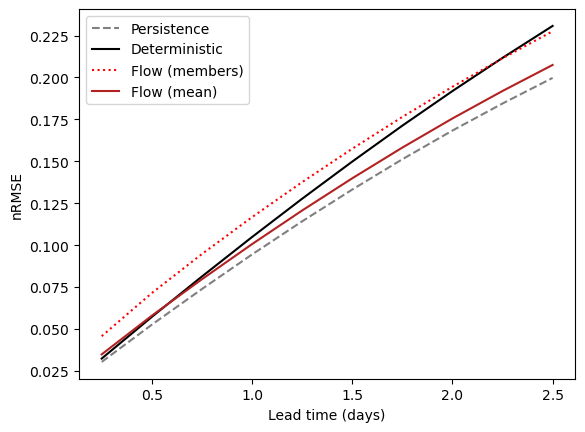

In [15]:
fig, ax = plt.subplots(dpi=100)

#ax.spines.left.set_position(("axes", 0.))
#ax.spines.right.set_color('none')
#ax.spines.bottom.set_position("zero")
#ax.spines.top.set_color('none')
ax.xaxis.set_ticks_position('bottom')
ax.yaxis.set_ticks_position('left')

ax.plot(
    lead_time_axis/pd.Timedelta("1 day"), np.sqrt((persistence_mse/in_std.squeeze().numpy()**2).mean(["time", "var_name"])),
    label="Persistence", c="0.5", ls="--")
ax.plot(
    lead_time_axis/pd.Timedelta("1 day"), np.sqrt((det_mse/in_std.squeeze().numpy()**2).mean(["time", "var_name"])),
    label="Deterministic", c="black", ls="-"
)
ax.plot(
    lead_time_axis/pd.Timedelta("1 day"), np.sqrt((flow_mse_ens/in_std.squeeze().numpy()**2).mean(["time", "var_name"])),
    label="Flow (members)", c="red", ls=":"
)
ax.plot(
    lead_time_axis/pd.Timedelta("1 day"), np.sqrt((flow_mse_mean/in_std.squeeze().numpy()**2).mean(["time", "var_name"])),
    label="Flow (mean)", c="firebrick"
)

ax.set_ylabel("nRMSE")
ax.set_xlabel("Lead time (days)") 

ax.legend()

# Plot prediction

In [18]:
ds_test.time.max().item()

710.0

In [19]:
start_time = ds_test.time.min().item()
end_time = ds_test.time.max().item()

In [20]:
sliced_truth = ds_test.sel(time=slice(start_time, end_time))
det_prediction = [sliced_truth[0].values[None]]

## Deterministic

In [21]:
for _ in tqdm(range(len(sliced_truth)-1)):
    net_io = torch.from_numpy(det_prediction[-1])
    net_io = ((net_io-in_mean) / in_std).to(device=device, dtype=dtype)
    with torch.no_grad():
        net_io = det_model(net_io).cpu().float()
    curr_prediction = det_prediction[-1] + (net_io * res_std + res_mean).numpy()
    det_prediction.append(curr_prediction)

det_prediction = np.concatenate(det_prediction, axis=0)
det_prediction = sliced_truth.copy(data=det_prediction)

  0%|          | 0/71 [00:00<?, ?it/s]

## Flow model

In [24]:
torch.manual_seed(42)
flow_prediction = [sliced_truth[0].values[None, None].repeat(n_ensemble, axis=0)]

for _ in tqdm(range(len(sliced_truth)-1)):
    last = flow_prediction[-1]  # shape: (n_ens, n_batch, C, H, W)
    n_ens, n_batch, C, H, W = last.shape
    with torch.no_grad():
        net_io = sample_with_flow(flow_model, n_samples=n_ens * n_batch, H=H, W=W)
        net_io = net_io.reshape(n_ens, n_batch, C, H, W).cpu().float()
    curr_prediction = flow_prediction[-1] + (net_io * res_std + res_mean).numpy()
    flow_prediction.append(curr_prediction)
flow_prediction = np.concatenate(flow_prediction, axis=1)
flow_prediction = sliced_truth.expand_dims(ensemble=np.arange(n_ensemble), axis=0).copy(data=flow_prediction)

  0%|          | 0/71 [00:00<?, ?it/s]

## Globe

In [25]:
def plot_q(q, ax=None, title=''):
    if ax is None:
        fig, ax = plt.subplots()
    qmax = np.max(q) 
    pc = ax.pcolormesh(
        np.linspace(0, 2*np.pi, q.shape[1]),
        np.linspace(0, 2*np.pi, q.shape[0]),
        q, cmap='seismic', vmin=-qmax, vmax=qmax
    )
    ax.set_aspect(1)
    ax.set_title(title)
    return pc

ValueError: For X (513) and Y (2) with flat shading, A should have shape (1, 512, 3) or (1, 512, 4) or (1, 512) or (512,), not (1, 512, 512)

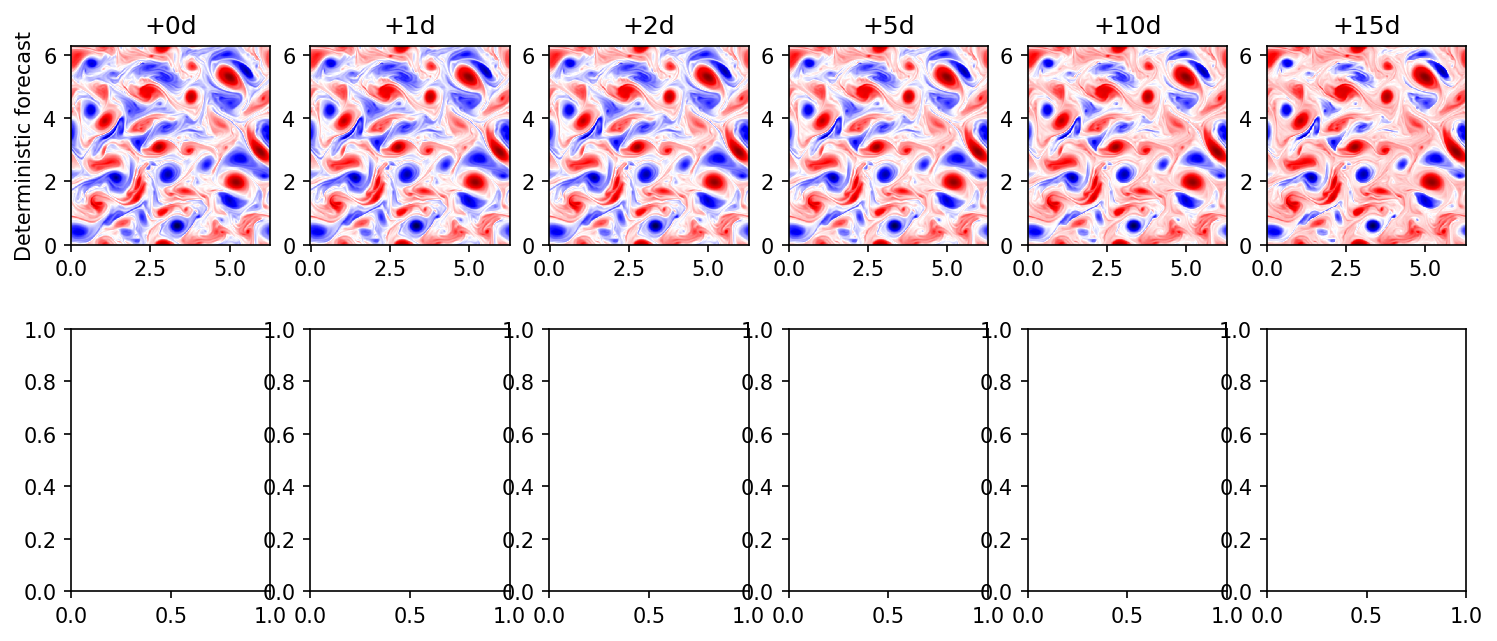

In [26]:
n_det_times = 6   # lead times to show for deterministic
n_flow_samples = 4  # ensemble members to show for flow

fig, axes = plt.subplots(
    nrows=2, ncols=max(n_det_times, n_flow_samples),
    figsize=(12, 5), dpi=150
)

# Row 1: deterministic forecast at increasing lead times
for i, td in enumerate([0, 4, 8, 20, 40, 60]):
    pc = plot_q(det_prediction[td, 0], ax=axes[0, i], title=f"+{td//4}d")
axes[0, 0].set_ylabel("Deterministic forecast")

# Row 2: flow matching samples (not forecasts — just generated states)
for i in range(n_flow_samples):
    pc = plot_q(flow_prediction[i, 0], ax=axes[1, i], title=f"Sample {i+1}")
# Hide unused axes
for i in range(n_flow_samples, axes.shape[1]):
    axes[1, i].set_visible(False)
axes[1, 0].set_ylabel("FM generated states")

plt.colorbar(pc, ax=axes, shrink=0.6)
plt.tight_layout()
plt.show()

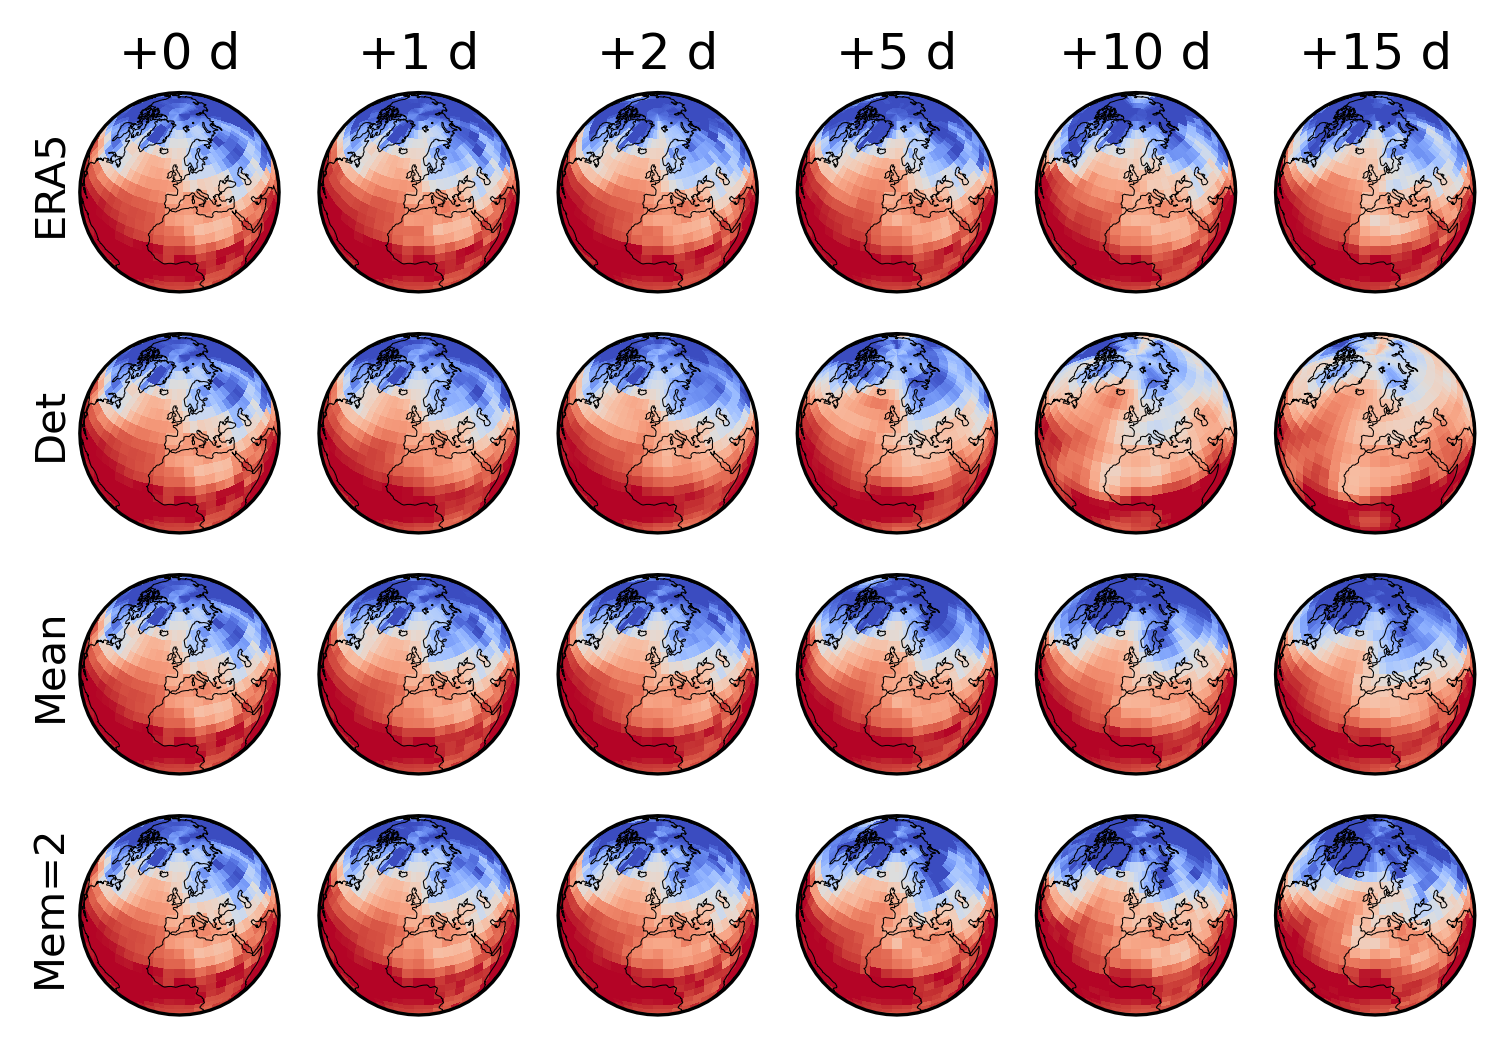

In [66]:
fig, ax = plt.subplots(
    ncols=6, nrows=4, figsize=(6, 4),
    subplot_kw={"projection": ccrs.NearsidePerspective(central_latitude=45)},
    dpi=300
)
for axi in ax:
    for axij in axi:
        axij.xaxis.set_visible(False)
        axij.yaxis.set_visible(False)
        axij.set_yticks([])
        axij.spines.left.set_visible(False)
        axij.spines.right.set_visible(False)
        axij.spines.bottom.set_visible(False)
        #axij.set_extent([-2_500_000, 2_000_000, -2_000_000, 2_500_000], ccrs.NorthPolarStereo())
        axij.add_feature(cartopy.feature.COASTLINE, zorder=98, lw=0.25)

ax[0, 0].text(x=-0.25, y=.55, s="ERA5", rotation=90, transform=ax[0, 0].transAxes, ha="left", va="center")
ax[1, 0].text(x=-0.25, y=.55, s="Det", rotation=90, transform=ax[1, 0].transAxes, ha="left", va="center")
ax[2, 0].text(x=-0.25, y=.55, s="Mean", rotation=90, transform=ax[2, 0].transAxes, ha="left", va="center")
ax[3, 0].text(x=-0.25, y=.55, s=f"Mem={member_to_plot+1:d}", rotation=90, transform=ax[3, 0].transAxes, ha="left", va="center")

for i, td in enumerate([0, 4, 8, 20, 40, 60]):
    ax[0, i].set_title("+{0:d} d".format(td//4))
    ax[0, i].pcolormesh(
        ds_test["longitude"], ds_test["latitude"], sliced_truth[td, 5].T-273.15,
        transform=ccrs.PlateCarree(), shading='nearest',
        cmap="coolwarm", vmin=-25, vmax=25
    )
    ax[1, i].pcolormesh(
        ds_test["longitude"], ds_test["latitude"], det_prediction[td, 5].T-273.15,
        transform=ccrs.PlateCarree(), shading='nearest',
        cmap="coolwarm", vmin=-25, vmax=25
    )
    ax[2, i].pcolormesh(
        ds_test["longitude"], ds_test["latitude"], flow_prediction[:, td, 5].mean(axis=0).T-273.15,
        transform=ccrs.PlateCarree(), shading='nearest',
        cmap="coolwarm", vmin=-25, vmax=25
    )
    ax[3, i].pcolormesh(
        ds_test["longitude"], ds_test["latitude"], flow_prediction[member_to_plot, td, 5].T-273.15,
        transform=ccrs.PlateCarree(), shading='nearest',
        cmap="coolwarm", vmin=-25, vmax=25
    )

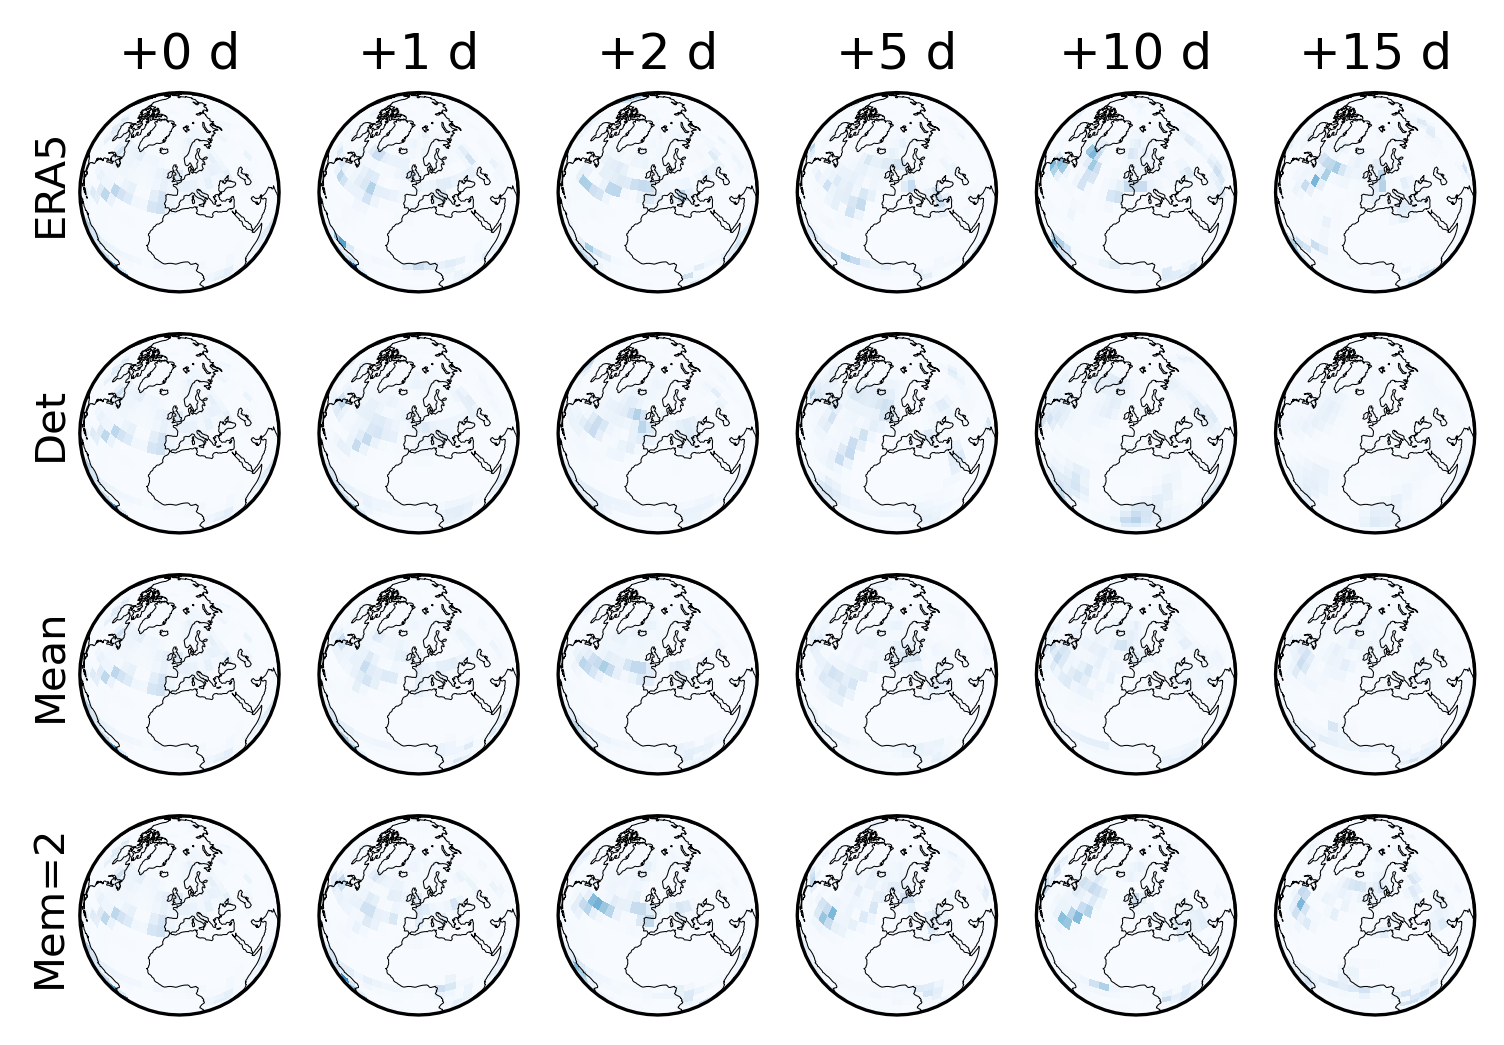

In [67]:
fig, ax = plt.subplots(
    ncols=6, nrows=4, figsize=(6, 4),
    subplot_kw={"projection": ccrs.NearsidePerspective(central_latitude=45)},
    dpi=300
)
for axi in ax:
    for axij in axi:
        axij.xaxis.set_visible(False)
        axij.yaxis.set_visible(False)
        axij.set_yticks([])
        axij.spines.left.set_visible(False)
        axij.spines.right.set_visible(False)
        axij.spines.bottom.set_visible(False)
        #axij.set_extent([-2_500_000, 2_000_000, -2_000_000, 2_500_000], ccrs.NorthPolarStereo())
        axij.add_feature(cartopy.feature.COASTLINE, zorder=98, lw=0.25)

ax[0, 0].text(x=-0.25, y=.55, s="ERA5", rotation=90, transform=ax[0, 0].transAxes, ha="left", va="center")
ax[1, 0].text(x=-0.25, y=.55, s="Det", rotation=90, transform=ax[1, 0].transAxes, ha="left", va="center")
ax[2, 0].text(x=-0.25, y=.55, s="Mean", rotation=90, transform=ax[2, 0].transAxes, ha="left", va="center")
ax[3, 0].text(x=-0.25, y=.55, s=f"Mem={member_to_plot+1:d}", rotation=90, transform=ax[3, 0].transAxes, ha="left", va="center")

for i, td in enumerate([0, 4, 8, 20, 40, 60]):
    ax[0, i].set_title("+{0:d} d".format(td//4))
    ax[0, i].pcolormesh(
        ds_test["longitude"], ds_test["latitude"], sliced_truth[td, 6].T,
        transform=ccrs.PlateCarree(), shading='nearest',
        cmap="Blues", vmin=0, vmax=0.02
    )
    ax[1, i].pcolormesh(
        ds_test["longitude"], ds_test["latitude"], det_prediction[td, 6].T,
        transform=ccrs.PlateCarree(), shading='nearest',
        cmap="Blues", vmin=0, vmax=0.02
    )
    ax[2, i].pcolormesh(
        ds_test["longitude"], ds_test["latitude"], flow_prediction[:, td, 6].mean(axis=0).T,
        transform=ccrs.PlateCarree(), shading='nearest',
        cmap="Blues", vmin=0, vmax=0.02
    )
    ax[3, i].pcolormesh(
        ds_test["longitude"], ds_test["latitude"], flow_prediction[member_to_plot, td, 6].T,
        transform=ccrs.PlateCarree(), shading='nearest',
        cmap="Blues", vmin=0, vmax=0.02
    )